<a href="https://colab.research.google.com/github/francesco-zatto/PIMA-ZSSR-vs-SRResNet/blob/main/SRResNet_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SRResNet Inspection

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image

## Model predictions

In [ ]:
# todo: dictionary approach per model

MODEL_NAME_1 = 'model_allOFF'
MODEL_NAME_2 = 'model_bnON_scalingOFF_tanhOFF'

MODEL_SHORT_1 = 'no BN'
MODEL_SHORT_2 = 'paper architecture'

root = '/content/drive/MyDrive/PIMA/'
zip_dir_1 = root + 'results/models/' + MODEL_NAME_1 + '/'
results_path_1 = root + 'results/models/' + MODEL_NAME_1 + '/outputs/srresnet/'
data_path = root + 'data/'
#models_path = root + 'results/models/checkpoints/'
log_path_1 = root + 'results/models/' + MODEL_NAME_1 + '/logs/' + MODEL_NAME_1 + '.txt'

zip_dir_2 = root + 'results/models/' + MODEL_NAME_2 + '/'
results_path_2 = root + 'results/models/' + MODEL_NAME_2 + '/outputs/srresnet/'
#models_path = root + 'results/models/checkpoints/'
log_path_2 = root + 'results/models/' + MODEL_NAME_2 + '/logs/' + MODEL_NAME_2 + '.txt'

## Training loss


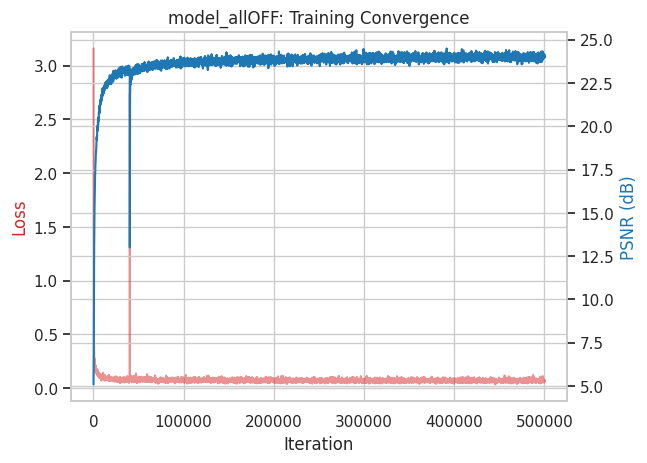

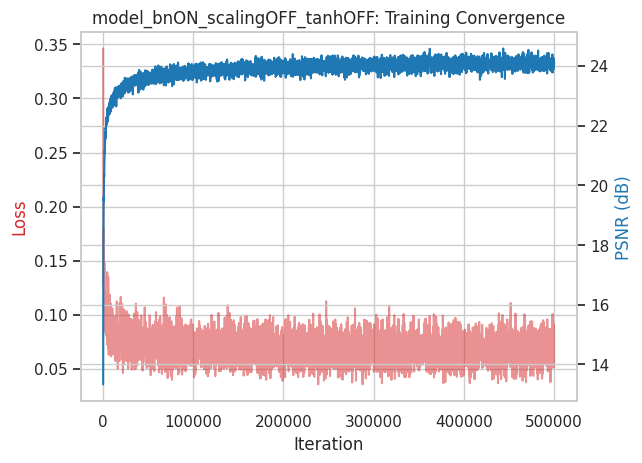

In [ ]:
import matplotlib.pyplot as plt
import re

def plot_training_log(log_file_path, model_name):
    iterations = []
    losses = []
    psnrs = []

    with open(log_file_path, 'r') as f:
        for line in f:
            # Extract numbers using regex
            it = re.search(r'Iteration (\d+)', line)
            loss = re.search(r'Loss: ([\d.]+)', line)
            psnr = re.search(r'PSNR: ([\d.]+)', line)

            if it and loss and psnr:
                iterations.append(int(it.group(1)))
                losses.append(float(loss.group(1)))
                psnrs.append(float(psnr.group(1)))

    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(iterations, losses, color='tab:red', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.set_ylabel('PSNR (dB)', color='tab:blue')
    ax2.plot(iterations, psnrs, color='tab:blue')

    plt.title(f'{model_name}: Training Convergence')
    plt.show()

plot_training_log(log_path_1, MODEL_NAME_1)
plot_training_log(log_path_2, MODEL_NAME_2)

## Unzip

In [ ]:
#unzip evaluation results

#zip_file_path = zip_dir + MODEL_NAME + '_results.tar.gz'
#print(zip_file_path)

#unzip and save to drive
#!tar -xzvf {zip_file_path} -C {zip_dir}

## Evaluation


In [ ]:
# data sets evaluated
BSD100_PATH = kagglehub.dataset_download("asilva1691/bsd100")
Urban100_PATH = kagglehub.dataset_download("harshraone/urban100")

Using Colab cache for faster access to the 'bsd100' dataset.
Using Colab cache for faster access to the 'urban100' dataset.


### BSD100

In [ ]:
#==================================================
#EVALUATION SUMMARY
#==================================================
#Checkpoint: srresnet_checkpoint_iter_860000.pth
#Scale Factor: 4x
#==================================================
#BSD100       -> PSNR:  24.74 dB, SSIM: 0.7098
#==================================================

In [ ]:
import numpy as np
from PIL import Image

def diagnose_image_files(hr_img, sr_img):
    """
    Analyzes raw pixel data from HR and SR image objects.
    Expects PIL Images or NumPy arrays (0-255).
    """
    # Convert to NumPy for math
    hr_arr = np.array(hr_img).astype(float)
    sr_arr = np.array(sr_img).astype(float)

    channels = ['Red', 'Green', 'Blue']

    print(f"{'Channel':<7} | {'HR Mean':<8} | {'SR Mean':<8} | {'HR Std':<8} | {'SR Std':<8}")
    print("-" * 55)

    for i, name in enumerate(channels):
        # Extract specific color channel
        h_c = hr_arr[:, :, i]
        s_c = sr_arr[:, :, i]

        h_m, s_m = np.mean(h_c), np.mean(s_c)
        h_s, s_s = np.std(h_c), np.std(s_c)

        print(f"{name:<7} | {h_m:8.2f} | {s_m:8.2f} | {h_s:8.2f} | {s_s:8.2f}")

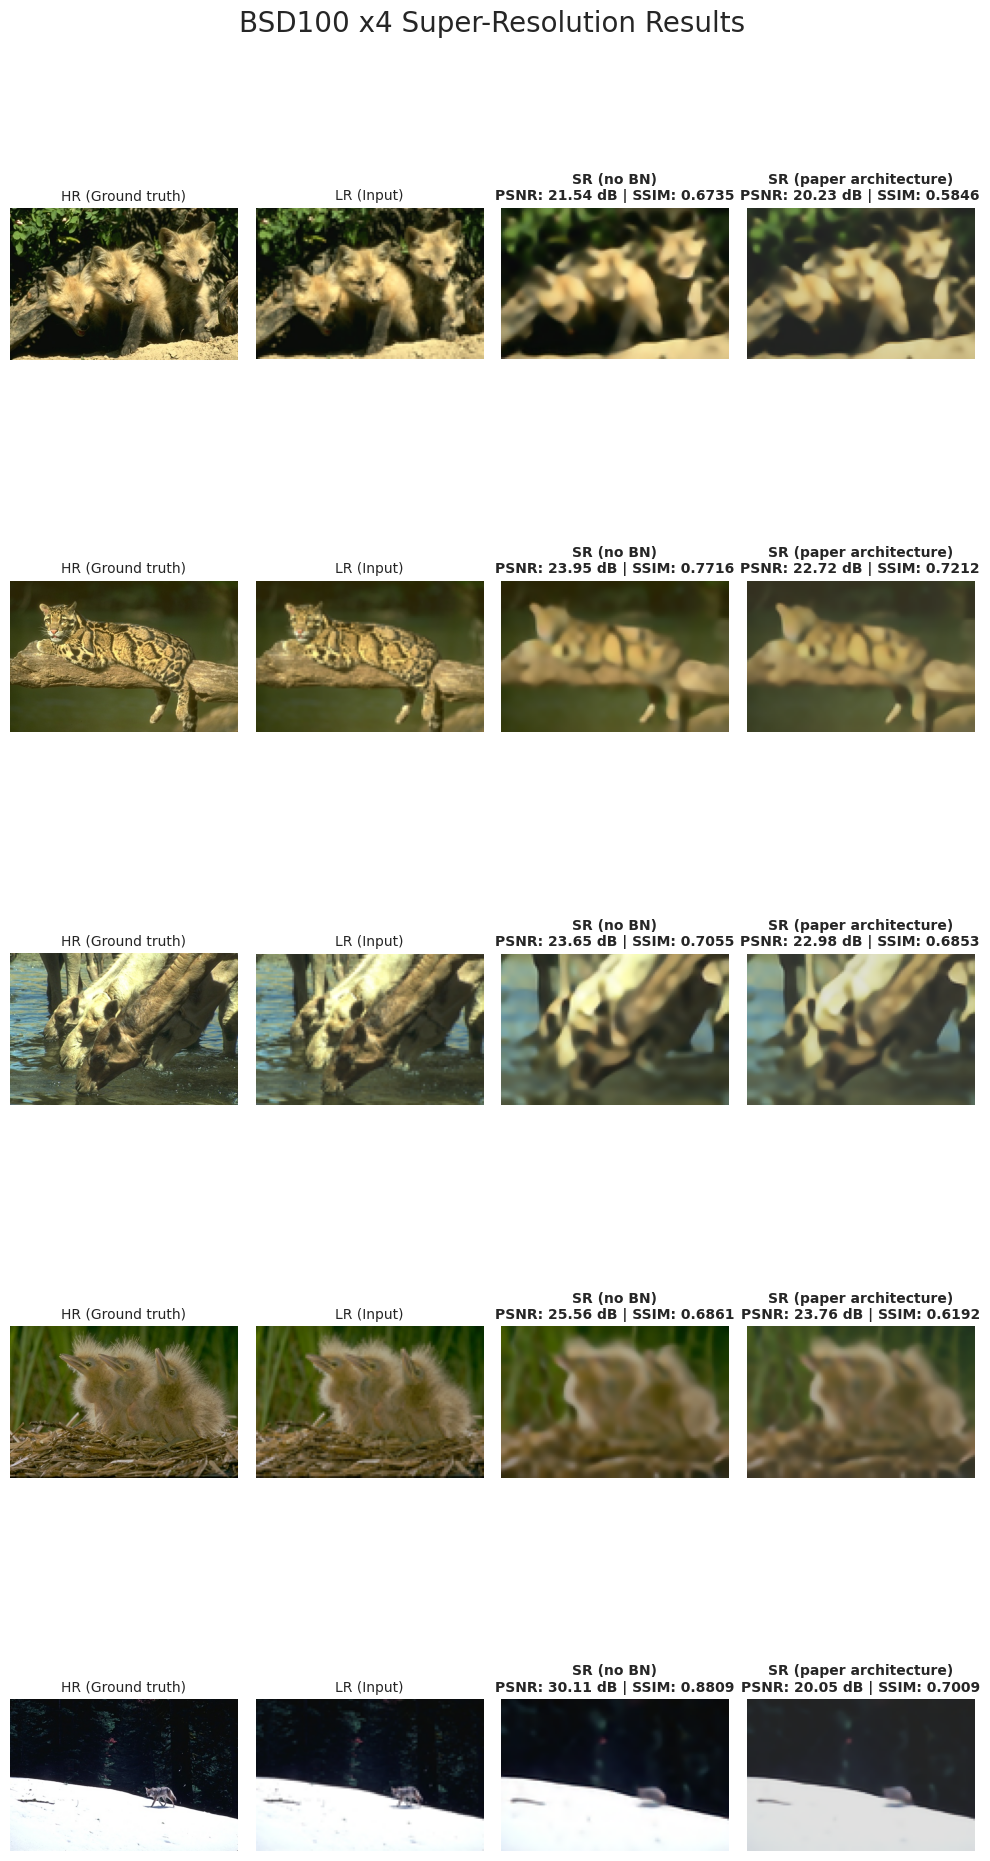

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd

# Target the specific x4 training folders
root_path = Path(BSD100_PATH)
hr_train_dir = next(root_path.rglob("**/bicubic_4x/train/HR"), None)
lr_train_dir = next(root_path.rglob("**/bicubic_4x/train/LR"), None)
sr_dir_1 = results_path_1 + 'bsd100/' + MODEL_NAME_1 + '/bsd100/'
sr_dir_2 = results_path_2 + 'bsd100/' + MODEL_NAME_2 + '/bsd100/'
metrics_df_bsd100_1 = pd.read_csv(Path(sr_dir_1) / 'srresnetrunner_evaluation_results.csv')
metrics_df_bsd100_1.set_index('Image_Name', inplace=True)
metrics_df_bsd100_2 = pd.read_csv(Path(sr_dir_2) / 'srresnetrunner_evaluation_results.csv')
metrics_df_bsd100_2.set_index('Image_Name', inplace=True)

if hr_train_dir and lr_train_dir:
    # First 5 images
    hr_images = sorted(list(hr_train_dir.glob("*.png")))[20:25]

    fig, axes = plt.subplots(5, 4, figsize=(10, 20))

    for i in range(5):
        # Filenames
        hr_path = hr_images[i]
        lr_path = lr_train_dir / hr_path.name
        sr_filename = Path(str(hr_path.name[:-4]) + "_SRResNet_pred.png")
        sr_path_1 = sr_dir_1 / sr_filename
        sr_path_2 = sr_dir_2 / sr_filename

        #hr = Image.open(hr_path)
        #sr = Image.open(sr_path)
        #diagnose_image_files(hr, sr)

        # HR
        axes[i, 0].imshow(Image.open(hr_path).convert("RGB"))
        axes[i, 0].set_title(f"HR (Ground truth)", fontsize=10)

        # LR
        axes[i, 1].imshow(Image.open(lr_path).convert("RGB"))
        axes[i, 1].set_title(f"LR (Input)", fontsize=10)

        # SR
        axes[i, 2].imshow(Image.open(sr_path_1).convert("RGB"))
        axes[i, 2].set_title(f"SR ({MODEL_SHORT_1}) ", fontsize=10
                             )
        axes[i, 3].imshow(Image.open(sr_path_2).convert("RGB"))
        axes[i, 3].set_title(f"SR ({MODEL_SHORT_2}) ", fontsize=10)
        # add metrics
        try:
          row1 = metrics_df_bsd100_1.loc[lr_path.name]
          psnr_val1 = row1['PSNR']
          ssim_val1 = row1['SSIM']
          row2 = metrics_df_bsd100_2.loc[lr_path.name]
          psnr_val2 = row2['PSNR']
          ssim_val2 = row2['SSIM']
          title_text1 = f"SR ({MODEL_SHORT_1})\nPSNR: {psnr_val1:.2f} dB | SSIM: {ssim_val1:.4f}"
          title_text2 = f"SR ({MODEL_SHORT_2})\nPSNR: {psnr_val2:.2f} dB | SSIM: {ssim_val2:.4f}"
          title_color = 'darkgreen'
        except KeyError:
          title_text1 = f"SR ({MODEL_SHORT_1})\n(Metrics not in CSV)"
          title_text2 = f"SR ({MODEL_SHORT_2})\n(Metrics not in CSV)"
          title_color = 'orange'
        axes[i, 2].set_title(title_text1, fontsize=10, fontweight='bold')
        axes[i, 3].set_title(title_text2, fontsize=10, fontweight='bold')

        # Formatting
        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.suptitle("BSD100 x4 Super-Resolution Results", fontsize=20, y=1.01)
    plt.show()
else:
    print(f"Path Error. \nHR Dir Found: {hr_train_dir} \nLR Dir Found: {lr_train_dir}")

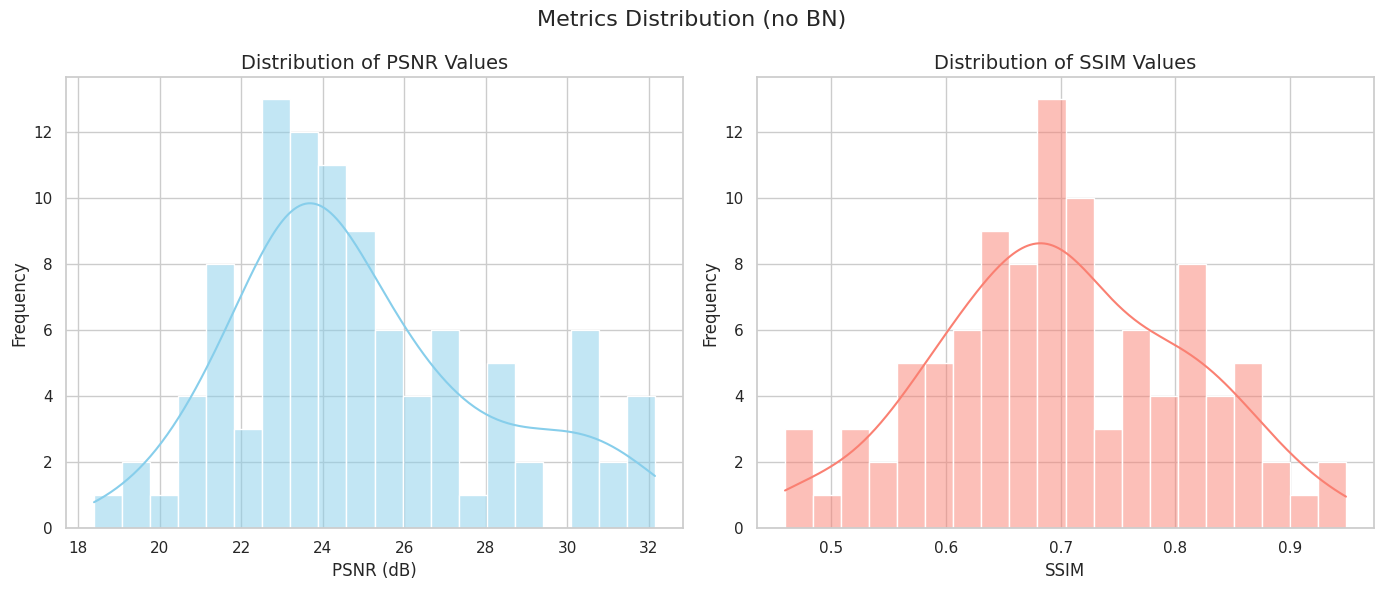

--- Summary Statistics (no BN) ---
           PSNR      SSIM
mean  24.935885  0.701261
std    3.114444  0.108246
min   18.393400  0.459600
max   32.151400  0.948900


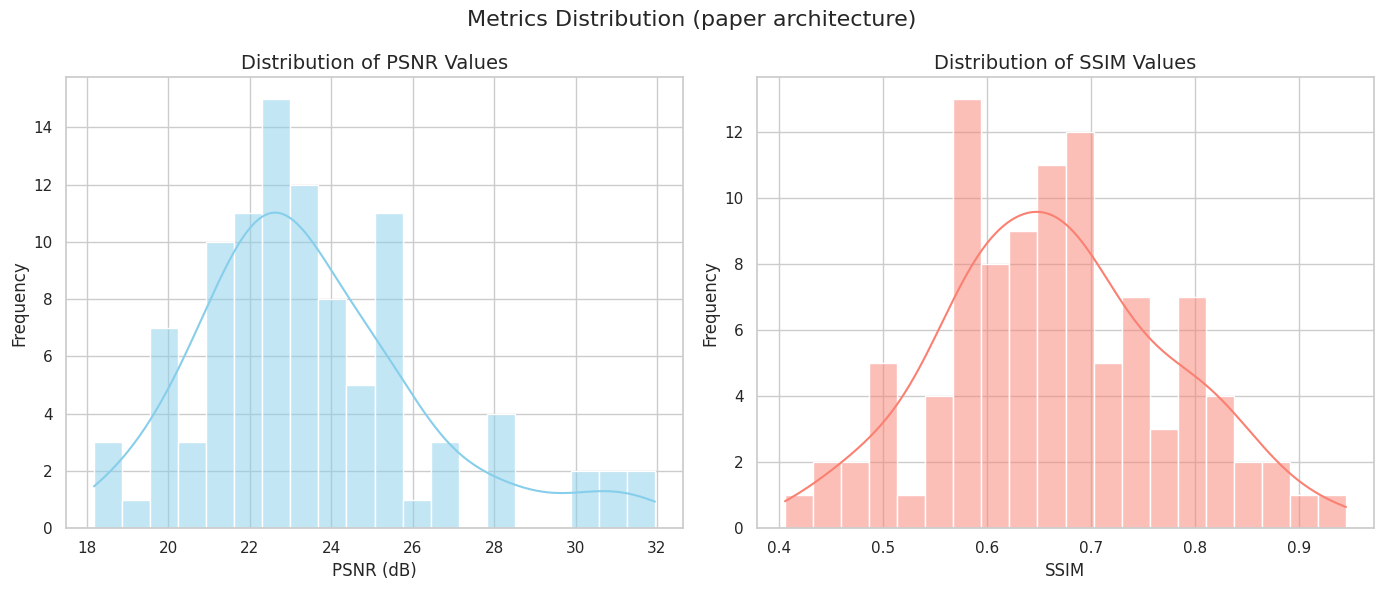

--- Summary Statistics (paper architecture) ---
           PSNR      SSIM
mean  23.518534  0.665366
std    2.847707  0.109299
min   18.182400  0.405700
max   31.950200  0.945200


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_metrics(model_name, df):
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Histogram for PSNR
    sns.histplot(df['PSNR'], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of PSNR Values', fontsize=14)
    axes[0].set_xlabel('PSNR (dB)')
    axes[0].set_ylabel('Frequency')

    # Histogram for SSIM
    sns.histplot(df['SSIM'], bins=20, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of SSIM Values', fontsize=14)
    axes[1].set_xlabel('SSIM')
    axes[1].set_ylabel('Frequency')

    # Overall title using the model name
    plt.suptitle(f"Metrics Distribution ({model_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Summary Statistics
    print(f"--- Summary Statistics ({model_name}) ---")
    print(df[['PSNR', 'SSIM']].describe().loc[['mean', 'std', 'min', 'max']])

plot_model_metrics(MODEL_SHORT_1, metrics_df_bsd100_1)
plot_model_metrics(MODEL_SHORT_2, metrics_df_bsd100_2)

### Urban100

In [ ]:
#==================================================
#EVALUATION SUMMARY
#==================================================
#Checkpoint: srresnet_checkpoint_iter_860000.pth
#Scale Factor: 4x
#==================================================
#Urban100     -> PSNR:  22.82 dB, SSIM: 0.7206
#==================================================

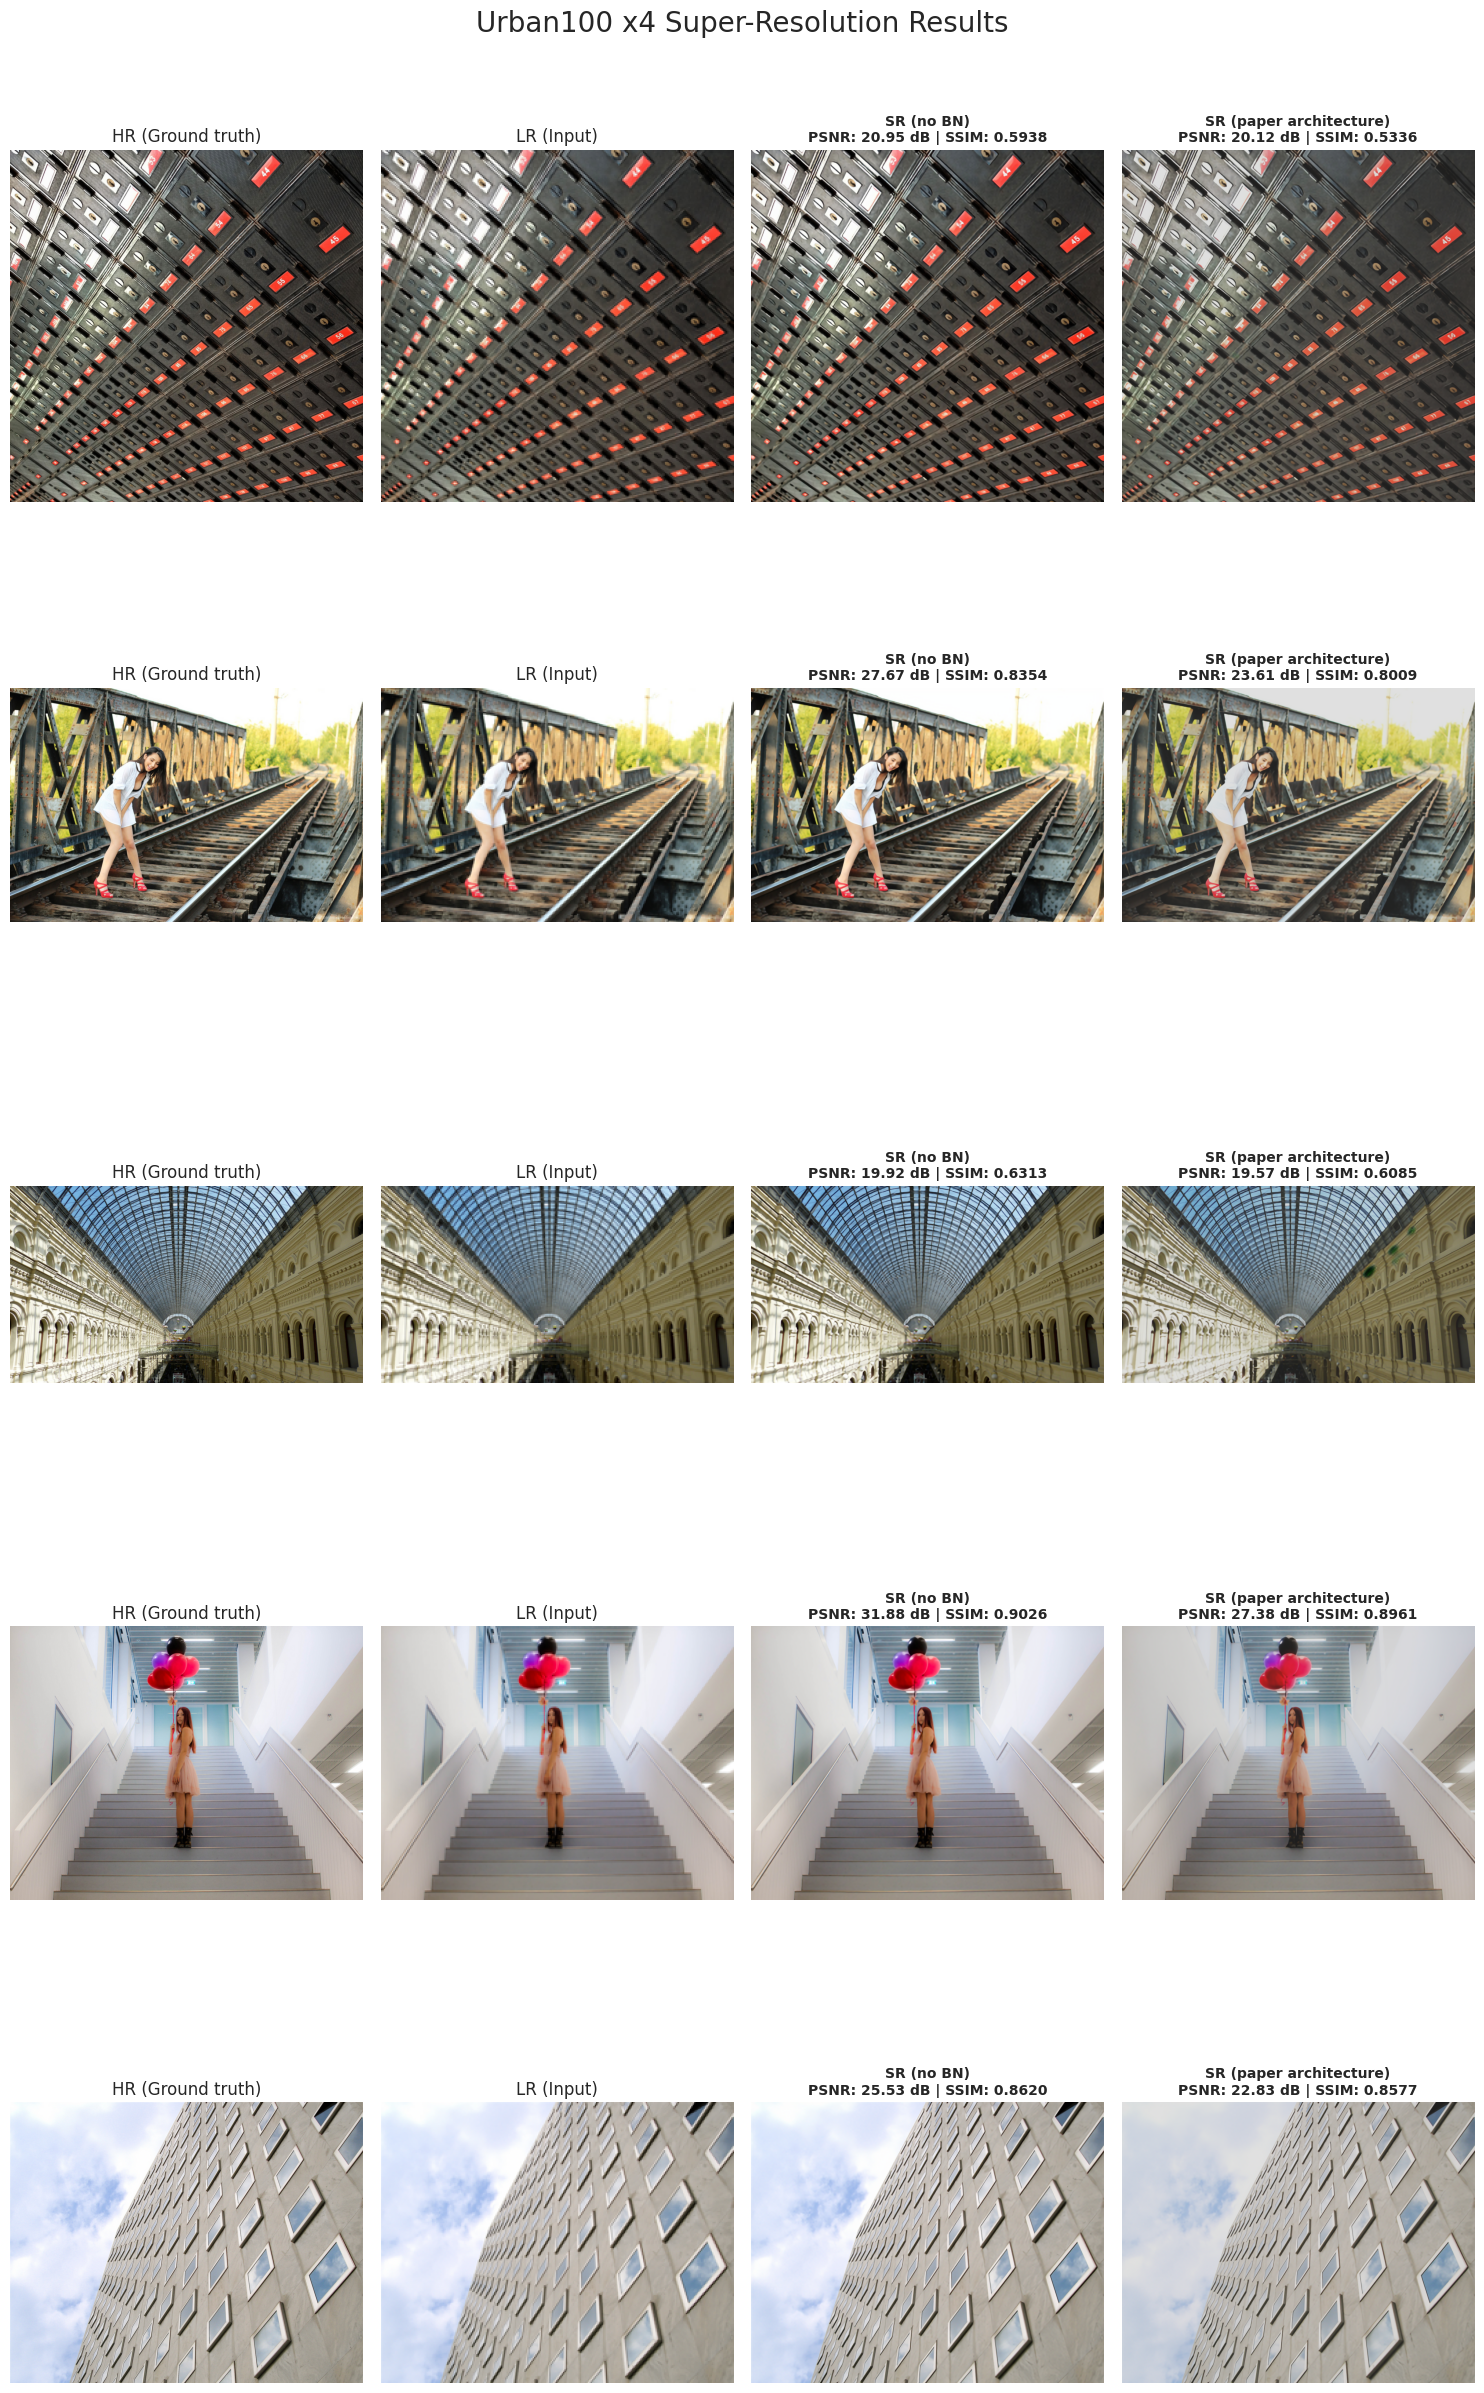

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd

# Paths
urban100_root = Path(Urban100_PATH)
hr_dir = next(urban100_root.rglob("HIGH x4 URban100"), None)
lr_dir = next(urban100_root.rglob("LOW x4 URban100"), None)

# Set up paths for both models
sr_dir_1 = results_path_1 + 'urban100/' + MODEL_NAME_1 + '/urban100/'
sr_dir_2 = results_path_2 + 'urban100/' + MODEL_NAME_2 + '/urban100/'

# Load metrics for both models
metrics_df_urban100_1 = pd.read_csv(Path(sr_dir_1) / 'srresnetrunner_evaluation_results.csv')
metrics_df_urban100_1.set_index('Image_Name', inplace=True)
metrics_df_urban100_2 = pd.read_csv(Path(sr_dir_2) / 'srresnetrunner_evaluation_results.csv')
metrics_df_urban100_2.set_index('Image_Name', inplace=True)

if hr_dir and lr_dir:
    hr_images = sorted(list(hr_dir.glob("*.png")))[5:10]

    # Changed from 5, 3 to 5, 4 to accommodate both models
    fig, axes = plt.subplots(5, 4, figsize=(15, 25))

    for i in range(5):
        # Filenames
        hr_path = hr_images[i]
        lr_path = lr_dir / f"{hr_path.stem[:-3]}_LR.png"
        sr_filename = f"{hr_path.stem[:-3]}_LR_SRResNet_pred.png"

        # Paths for both models
        sr_path_1 = Path(sr_dir_1) / sr_filename
        sr_path_2 = Path(sr_dir_2) / sr_filename

        # hr = Image.open(hr_path)
        # sr = Image.open(sr_path_1)
        # diagnose_image_files(hr, sr)

        # HR
        axes[i, 0].imshow(Image.open(hr_path).convert("RGB"))
        axes[i, 0].set_title(f"HR (Ground truth)", fontsize=12)

        # LR
        axes[i, 1].imshow(Image.open(lr_path).convert("RGB"))
        axes[i, 1].set_title(f"LR (Input)", fontsize=12)

        # SR Model 1
        axes[i, 2].imshow(Image.open(sr_path_1).convert("RGB"))

        # SR Model 2
        axes[i, 3].imshow(Image.open(sr_path_2).convert("RGB"))

        # Add metrics for both models
        try:
            row1 = metrics_df_urban100_1.loc[lr_path.name]
            psnr_val1 = row1['PSNR']
            ssim_val1 = row1['SSIM']

            row2 = metrics_df_urban100_2.loc[lr_path.name]
            psnr_val2 = row2['PSNR']
            ssim_val2 = row2['SSIM']

            title_text1 = f"SR ({MODEL_SHORT_1})\nPSNR: {psnr_val1:.2f} dB | SSIM: {ssim_val1:.4f}"
            title_text2 = f"SR ({MODEL_SHORT_2})\nPSNR: {psnr_val2:.2f} dB | SSIM: {ssim_val2:.4f}"
        except KeyError:
            title_text1 = f"SR ({MODEL_SHORT_1})\n(Metrics not in CSV)"
            title_text2 = f"SR ({MODEL_SHORT_2})\n(Metrics not in CSV)"

        axes[i, 2].set_title(title_text1, fontsize=10, fontweight='bold')
        axes[i, 3].set_title(title_text2, fontsize=10, fontweight='bold')

        # Formatting across all 4 columns
        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    # Adjusted y position slightly so title doesn't overlap the top row
    plt.suptitle("Urban100 x4 Super-Resolution Results", fontsize=20, y=1.01)
    plt.show()
else:
    print(f"Path Error. \nHR Dir Found: {hr_dir} \nLR Dir Found: {lr_dir}")

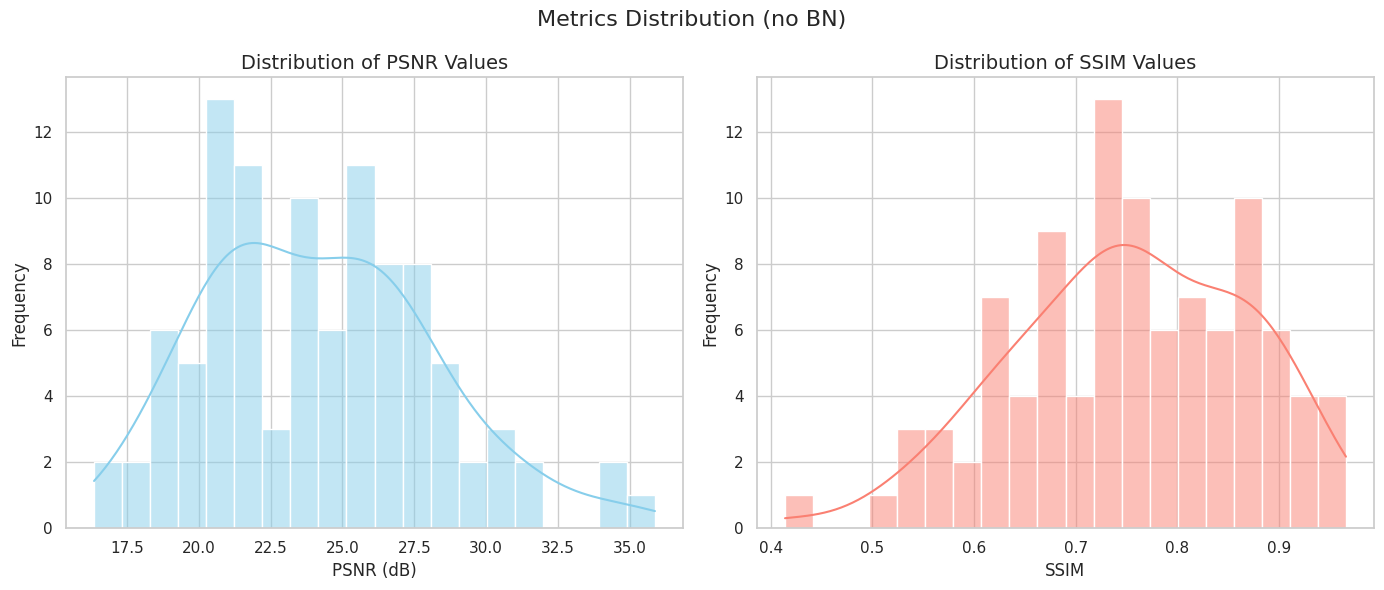

--- Summary Statistics (no BN) ---
           PSNR      SSIM
mean  24.217173  0.753665
std    3.987429  0.114477
min   16.362000  0.413900
max   35.867600  0.966200


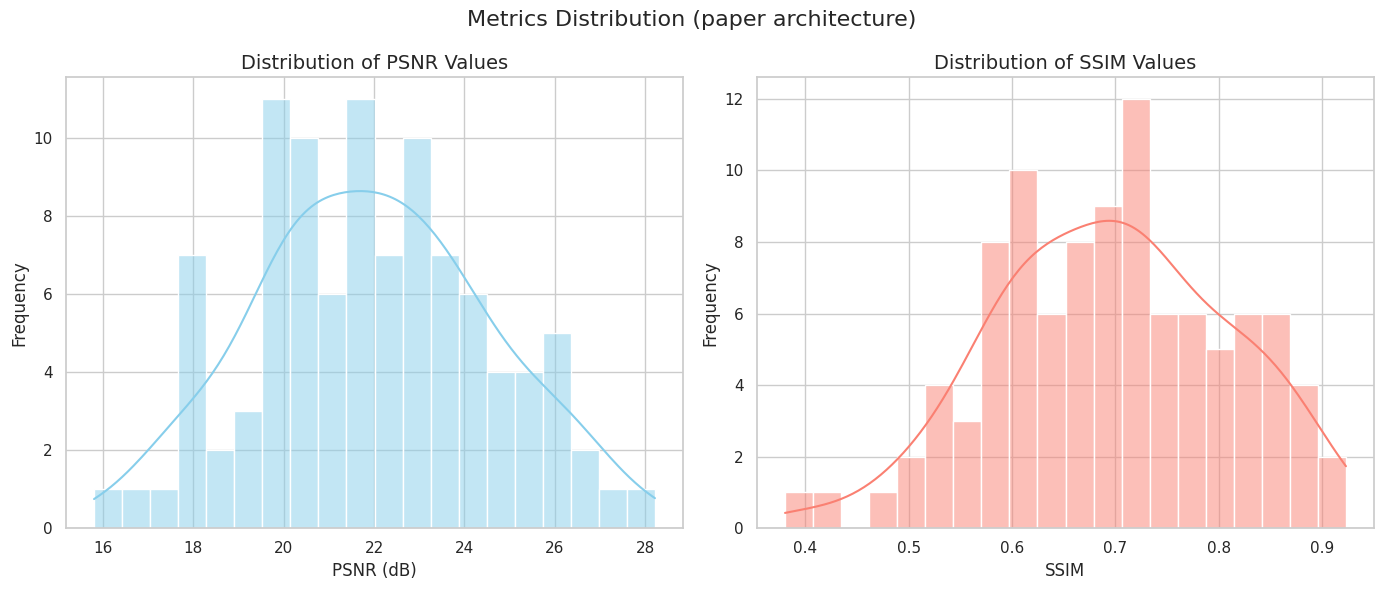

--- Summary Statistics (paper architecture) ---
           PSNR      SSIM
mean  21.956145  0.694513
std    2.583342  0.112649
min   15.805700  0.380300
max   28.214100  0.923000


In [ ]:
plot_model_metrics(MODEL_SHORT_1, metrics_df_urban100_1)
plot_model_metrics(MODEL_SHORT_2, metrics_df_urban100_2)

## Model definition

In [ ]:
import torch
import torch.nn as nn

class ConvBlock(torch.nn.Module):
    """
    A basic convolutional block consisting of a convolution followed by a PReLU activation
    with optional batch normalization.
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, normalize=True, activation=True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size//2)
        self.batch_norm = nn.BatchNorm2d(out_channels) if normalize else None
        self.prelu = nn.PReLU() if activation else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        if self.batch_norm is not None:
            x = self.batch_norm(x)
        return self.prelu(x)

class ResidualBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, normalize=True):
        super().__init__()
        self.conv1 = ConvBlock(in_channels, out_channels, kernel_size, normalize)
        self.conv2 = ConvBlock(out_channels, out_channels, kernel_size, normalize, activation=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.conv1(x)
        x = self.conv2(x)
        return x + residual

class SubPixelConvBlock(torch.nn.Module):
    def __init__(self, in_channels: int, upscale_factor: int = 2):
        super().__init__()
        out_channels = in_channels * (upscale_factor ** 2)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=upscale_factor)
        self.prelu = nn.PReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        return self.prelu(x)

class SRResNet(nn.Module):
    """
    SRResNet architecture based on the paper by Ledig et al. (2017).
    """
    def __init__(self, num_channels: int = 64, num_blocks: int = 16, upscale_factor: int = 4):
        super().__init__()
        self.num_channels = num_channels
        self.num_blocks = num_blocks
        self.upscale_factor = upscale_factor
        self.initial_conv = ConvBlock(in_channels=3, out_channels=num_channels, kernel_size=9, normalize=False)
        self.residual_blocks = nn.Sequential(*[ResidualBlock(in_channels=num_channels, out_channels=num_channels) for _ in range(num_blocks)])
        self.secondary_conv = ConvBlock(in_channels=num_channels, out_channels=num_channels, kernel_size=3, normalize=True, activation=False)

        if upscale_factor == 4:
            self.upsample = nn.Sequential(
                SubPixelConvBlock(num_channels, 2),
                SubPixelConvBlock(num_channels, 2)
            )
        else:
            self.upsample = SubPixelConvBlock(num_channels, upscale_factor)

        self.final_conv = ConvBlock(in_channels=num_channels, out_channels=3, kernel_size=9, normalize=False, activation=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.initial_conv(x)
        residual = x
        x = self.residual_blocks(x)
        x = self.secondary_conv(x)
        x = x + residual # Global skip connection
        x = self.upsample(x)
        x = self.final_conv(x)
        return torch.tanh(x)


#### Further definitions

In [ ]:
import torch
import numpy as np
import random
import glob
import os
import torchvision.transforms as transforms
import torchvision.transforms.functional as transformsF
from abc import ABC, abstractmethod
from PIL import Image

#from data.utils import augment

class SRPreprocessingStrategy(ABC):
    """
    Interface for SR data handling.
    """
    @abstractmethod
    def prepare(self, root_dir: str, ext: str) -> None:
        """Initializes the strategy's internal state."""
        pass

    @abstractmethod
    def sample(self, idx: int, scale_factor: float) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns a single (LR, HR) pair."""
        pass

    @abstractmethod
    def __len__(self) -> int:
        """Returns the virtual length of the dataset."""
        pass

    @abstractmethod
    def update(self, new_hrs: list[torch.Tensor]) -> None:
        """
        Updates the dataset by adding the list of new HRs images.
        """
        pass

class ResNetPreprocessing(SRPreprocessingStrategy):
    def __init__(self, crop_size=96, train=True):
        self.crop_size = crop_size
        self.train = train
        self.img_paths = []

    def prepare(self, root_dir: str, ext: str):
        search_path = os.path.join(root_dir, "**", ext)
        self.img_paths = glob.glob(search_path, recursive=True)

    def sample(self, idx: int, scale_factor: float) -> tuple[torch.Tensor, torch.Tensor]:
        hr_img = Image.open(self.img_paths[idx]).convert('RGB')
        hr_tensor = transformsF.to_tensor(hr_img)

        if self.train:
            # use random crops
            # Check if the image is too small for the crop
            if hr_img.width < self.crop_size or hr_img.height < self.crop_size:
                print(f"Skipping {self.img_paths[idx]} (Size: {hr_img.width}x{hr_img.height}) - too small for {self.crop_size}x{self.crop_size} crop.")

                # Pick a new random index and try again recursively
                new_index = random.randint(0, len(self.img_paths) - 1)
                return self.sample(new_index, scale_factor)
            i, j, h, w = transforms.RandomCrop.get_params(hr_tensor, (self.crop_size, self.crop_size))
            hr_target = transformsF.crop(hr_tensor, i, j, h, w)

        else:
            # use full image
            h, w = hr_tensor.shape[1], hr_tensor.shape[2]
            new_size = (h // int(scale_factor)) * int(scale_factor), (w // int(scale_factor)) * int(scale_factor)
            hr_target = transformsF.center_crop(hr_tensor, list(new_size))

         # Generate LR image
        lr_size = (hr_target.shape[1] // int(scale_factor), hr_target.shape[2] // int(scale_factor))
        lr_target = transformsF.resize(hr_target, list(lr_size), interpolation=transforms.InterpolationMode.BICUBIC)

        # Scale HR to [-1, 1] according to paper
        hr_target = (hr_target * 2.0) - 1.0

        return lr_target, hr_target

    def __len__(self):
        return len(self.img_paths)

    def update(self, new_hrs: list[torch.Tensor]) -> None:
        # No dynamic updates needed for ResNet strategy
        pass


In [ ]:
import torch
from torch.utils.data import Dataset
from abc import ABC

import torch
import numpy as np
import random
import glob
import os
import torchvision.transforms as transforms
import torchvision.transforms.functional as transformsF
from abc import ABC, abstractmethod
from PIL import Image


class SRPreprocessingStrategy(ABC):
    """
    Interface for SR data handling.
    """
    @abstractmethod
    def prepare(self, root_dir: str, ext: str) -> None:
        """Initializes the strategy's internal state."""
        pass

    @abstractmethod
    def sample(self, idx: int, scale_factor: float) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns a single (LR, HR) pair."""
        pass

    @abstractmethod
    def __len__(self) -> int:
        """Returns the virtual length of the dataset."""
        pass

    @abstractmethod
    def update(self, new_hrs: list[torch.Tensor]) -> None:
        """
        Updates the dataset by adding the list of new HRs images.
        """
        pass

class ResNetPreprocessing(SRPreprocessingStrategy):
    def __init__(self, crop_size=96, train=True):
        self.crop_size = crop_size
        self.train = train
        self.img_paths = []

    def prepare(self, root_dir: str, ext: str):
        search_path = os.path.join(root_dir, "**", ext)
        self.img_paths = glob.glob(search_path, recursive=True)

    def sample(self, idx: int, scale_factor: float) -> tuple[torch.Tensor, torch.Tensor]:
        hr_img = Image.open(self.img_paths[idx]).convert('RGB')
        hr_tensor = transformsF.to_tensor(hr_img)

        if self.train:
            # use random crops
            # Check if the image is too small for the crop
            if hr_img.width < self.crop_size or hr_img.height < self.crop_size:
                print(f"Skipping {self.img_paths[idx]} (Size: {hr_img.width}x{hr_img.height}) - too small for {self.crop_size}x{self.crop_size} crop.")

                # Pick a new random index and try again recursively
                new_index = random.randint(0, len(self.img_paths) - 1)
                return self.sample(new_index, scale_factor)
            i, j, h, w = transforms.RandomCrop.get_params(hr_tensor, (self.crop_size, self.crop_size))
            hr_target = transformsF.crop(hr_tensor, i, j, h, w)

        else:
            # use full image
            h, w = hr_tensor.shape[1], hr_tensor.shape[2]
            new_size = (h // int(scale_factor)) * int(scale_factor), (w // int(scale_factor)) * int(scale_factor)
            hr_target = transformsF.center_crop(hr_tensor, list(new_size))

         # Generate LR image
        lr_size = (hr_target.shape[1] // int(scale_factor), hr_target.shape[2] // int(scale_factor))
        lr_target = transformsF.resize(hr_target, list(lr_size), interpolation=transforms.InterpolationMode.BICUBIC)

        # Scale HR to [-1, 1] according to paper
        hr_target = (hr_target * 2.0) - 1.0

        return lr_target, hr_target

    def __len__(self):
        return len(self.img_paths)

    def update(self, new_hrs: list[torch.Tensor]) -> None:
        # No dynamic updates needed for ResNet strategy
        pass


class ZSSRPreprocessing(SRPreprocessingStrategy):
    """
    Self-Supervised Strategy: Manages internal patch recurrence pools.
    """
    def __init__(self, num_patches=1000, num_hr_scales=6, crop_size=128):
        self.num_patches = num_patches
        self.num_hr_scales = num_hr_scales
        self.crop_size = crop_size
        self.pool_fathers: list[torch.Tensor] = []
        self.father_weights: list[float] = []
        self.base_img: torch.Tensor = None

    def prepare(self, root_dir: str, ext: str):
        """
        Create initial dataset from test_img.
        """
        image_path = glob.glob(os.path.join(root_dir, ext))[0]
        self.base_img = self._load_image(image_path)
        self._add_downsampled_versions(self.base_img)

    def _load_image(self, image_path: str) -> torch.Tensor:
        """
        Read image as PIL.Image and then convert to tensor in [0, 1] range
        """
        return transformsF.to_tensor(Image.open(image_path).convert('RGB'))

    def _add_downsampled_versions(self, img: torch.Tensor):
        """
        Create self.num_hr_scales downsampled versions of img to increase the HRs pool.
        """
        hr_scales = np.linspace(1.0, 0.8, self.num_hr_scales)
        _, h, w = img.shape
        for s in hr_scales:
            new_h, new_w = int(h * s), int(w * s)
            resized = transformsF.resize(img, (new_h, new_w),
                                         interpolation=transforms.InterpolationMode.BICUBIC)
            self._add_to_pool(resized)

    def _add_to_pool(self, hr_image: torch.Tensor):
        """
        Add an image to the pool of HR father images, computing its sampling probability.
        """
        augmented_images = augment(hr_image)

        hr_area = hr_image.shape[1] * hr_image.shape[2]
        base_area = self.base_img.shape[1] * self.base_img.shape[2]
        size_ratio = hr_area / base_area

        # Weight proportional to how close are to base_img size
        weight = size_ratio if size_ratio <= 1.0 else 1.0 / size_ratio

        self.pool_fathers.extend(augmented_images)
        self.father_weights.extend([weight] * len(augmented_images))

    def sample(self, idx: int, scale_factor: float) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Sample a HR father according to the probability distribution derived by ratios with original LR size.
        From HR, take a patch and create a LR to use as input for the model.
        """
        hr_father = random.choices(self.pool_fathers, weights=self.father_weights, k=1)[0]
        hr_crop = self._crop(hr_father)

        lr_size = (int(hr_crop.shape[1] / scale_factor), int(hr_crop.shape[2] / scale_factor))
        lr_crop = transformsF.resize(hr_crop, lr_size, interpolation=transforms.InterpolationMode.BICUBIC)

        return lr_crop, hr_crop

    def _crop(self, hr_image: torch.Tensor) -> torch.Tensor:
        """
        Take a random crop of HR image if HR is large enough.
        """
        _, h, w = hr_image.shape
        if h < self.crop_size or w < self.crop_size:
            return hr_image
        i, j, th, tw = transforms.RandomCrop.get_params(hr_image, (self.crop_size, self.crop_size))
        return transformsF.crop(hr_image, i, j, th, tw)

    def __len__(self):
        return self.num_patches

    def update(self, new_hrs: list[torch.Tensor]) -> None:
        for hr in new_hrs:
            self._add_downsampled_versions(hr)



class AbstractSRDataset(Dataset, ABC):
    """
    Generic SISR Dataset that delegate preprocessing operations to a SRPreprocessingStrategy.
    """
    def __init__(self, root_dir: str, scale_factor: float, strategy: SRPreprocessingStrategy, ext: str):
        self.scale_factor = self.curr_s_i = scale_factor
        self.strategy = strategy

        self.strategy.prepare(root_dir, ext)

    def __len__(self) -> int:
        return len(self.strategy)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self._check(self.strategy.sample(idx, self.curr_s_i))

    def add_image(self, image: torch.Tensor) -> None:
        """
        Add to the dataset the new image, using the preprocessing strategy.
        """
        new_pairs = self.strategy.update([image])

    def _check(self, item: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Apply final check to LR and HR images, i.e. clamping them between 0.0 and 1.0.
        """
        lr_img, hr_img = item
        return torch.clamp(lr_img, 0.0, 1.0), torch.clamp(hr_img, 0.0, 1.0)


class Urban100Dataset(AbstractSRDataset):
    # TODO their root_dir should be a constant for ResNet and a given dir for ZSSR depending on the test image
    def __init__(self, root_dir: str, scale_factor: float, strategy: SRPreprocessingStrategy):
        super().__init__(root_dir, scale_factor, strategy, ext="*.png")

class BSD100Dataset(AbstractSRDataset):
    def __init__(self, root_dir: str, scale_factor: float, strategy: SRPreprocessingStrategy):
        super().__init__(root_dir, scale_factor, strategy, ext="*.png")

# for training ResNet
class COCODataset(AbstractSRDataset):
    def __init__(self, root_dir: str, scale_factor: float, strategy: SRPreprocessingStrategy):
        super().__init__(root_dir, scale_factor, strategy, ext="*.jpg")

In [ ]:
class AbstractRunner(ABC):

    @abstractmethod
    def train(self, dataset: AbstractSRDataset, **kwargs) -> None:
        """
        Trains the model on the provided dataset.
        """
        pass

    @abstractmethod
    def evaluate(self, dataset: AbstractSRDataset, **kwargs) -> dict:
        """
        Predict HR images and return a dict of metrics.
        """
        pass

class SRResNetRunner(AbstractRunner):
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.criterion = nn.L1Loss()
        self.learning_rate = 1e-4
        self.model = None

        self.metrics = SRMetricSuite(self.device)

    def train(self, dataset, total_iterations, batch_size, checkpoint_save_path=None, checkpoint_load_path=None):
        self.model = SRResNet().to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate, betas=(0.9, 0.999))
        current_iteration = 0

        # 2. Load checkpoint if path is provided
        if checkpoint_load_path is not None:
            print(f"--- Resuming training from checkpoint: {checkpoint_load_path} ---")
            # We overwrite model, optimizer, and the starting iteration count
            self.model, optimizer, current_iteration = self._load_checkpoint(checkpoint_load_path)
        else:
            # If starting from scratch, apply weight initialization
            def init_weights(m):
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            self.model.apply(init_weights)
            print(f"--- Starting training from scratch ---")

        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        print(f"--- Training SRResNet for {total_iterations} total iterations ---")

        self.model.train()
        self.metrics.reset() # Clear metrics before starting

        # start time
        t0 = time.time()
        epoch_t0 = time.time()

        epoch = 0
        while current_iteration < total_iterations:
            epoch += 1
            print(f"--- Starting Epoch {epoch} ---")
            for lr_im, hr_im in dataloader:
                if current_iteration >= total_iterations:
                    break

                lr_patch, hr_true = lr_im.to(self.device), hr_im.to(self.device)

                optimizer.zero_grad()
                hr_pred = self.model(lr_patch)
                loss = self.criterion(hr_pred, hr_true)
                loss.backward()
                optimizer.step()

                # metrics
                # Detach from the graph to prevent memory leaks during tracking!
                sr_01 = self._standardize_output(hr_pred.detach())
                hr_01 = self._standardize_output(hr_true.detach())
                self.metrics.update(sr_01, hr_01)

                current_iteration += 1

                # Log loss and metrics every 100 iterations
                if current_iteration % 100 == 0:
                    results = self.metrics.compute()
                    print(f"Iteration {current_iteration}/{total_iterations}, "
                          f"Loss: {loss.item():.6f}, "
                          f"Train PSNR: {results['psnr']:.2f} dB, "
                          f"Train SSIM: {results['ssim']:.4f}, ")

                    # Reset metrics so the next print reflects just the last 100 iterations
                    self.metrics.reset()

                # Save checkpoint every 5000 iterations
                if current_iteration % 5000 == 0:
                    dir_path = checkpoint_save_path if checkpoint_save_path is not None else ""
                    self._save_checkpoint(
                        current_iteration,
                        self.model,
                        optimizer,
                        f"{dir_path}/srresnet_checkpoint_iter_{current_iteration}.pth"
                    )
                    print(f"Checkpoint saved at iteration {current_iteration}.")

            # log epoch time unconditionally
            print(f"End of epoch (Iteration {current_iteration}), Loss: {loss.item():.6f}")
            t1 = time.time()
            print(f"Time taken for epoch: {t1 - epoch_t0:.2f} seconds")

            # reset epoch timer for the next pass
            epoch_t0 = time.time()

        # end time
        t_end = time.time()
        print(f"Total training time: {t_end - t0:.2f} seconds")

        if checkpoint_save_path is not None:
            final_path = Path(checkpoint_save_path) / "srresnet_final.pth"
            self._save_checkpoint(
                current_iteration,
                self.model,
                optimizer,
                final_path
            )
            print(f"Final model saved to {final_path}")

        return self.metrics.compute()

    def _save_checkpoint(self, iteration, model, optimizer, path):
        checkpoint = {
            'iteration': iteration,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }
        torch.save(checkpoint, path)

    def _load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        model = SRResNet().to(self.device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer = optim.Adam(model.parameters(), lr=self.learning_rate, betas=(0.9, 0.999))
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        iteration = checkpoint['iteration']
        return model, optimizer, iteration

    def _standardize_output(self, hr_pred):
        """
        Convert model output from [-1, 1] to [0, 1] for metric calculation.
        """
        return (hr_pred + 1.0) / 2.0


    def evaluate(self, dataset, checkpoint_path=None):
        dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

        if checkpoint_path is not None:
            print(f"Loading checkpoint from {checkpoint_path}...")
            self.model, _, _ = self._load_checkpoint(checkpoint_path)
        elif self.model is None:
            raise ValueError("Model has not been trained yet and no checkpoint was provided. Please train the model or provide a checkpoint_path.")

        self.model.eval()
        self.metrics.reset() # Clear previous scores

        print("--- Evaluating Model ---")

        with torch.no_grad():
            for lr_im, hr_im in dataloader:
                lr_patch, hr_true = lr_im.to(self.device), hr_im.to(self.device)

                # forward pass
                hr_pred = self.model(lr_patch)

                # Standardize both to [0, 1] before metric collection
                # hr_pred is [-1, 1], hr_true is [-1, 1]
                sr_01 = self._standardize_output(hr_pred)
                hr_01 = self._standardize_output(hr_true)

                # update metrics
                self.metrics.update(sr_01, hr_01)

        # Calculate the final average scores
        results = self.metrics.compute()

        print(f"Results -> PSNR: {results['psnr']:.2f} dB, SSIM: {results['ssim']:.4f}")
        return results, sr_01

In [ ]:
import torch
!pip install torchmetrics
from torchmetrics import MetricCollection

from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

class SRMetricSuite:
    def __init__(self, device):
        metrics = MetricCollection({
            'psnr': PeakSignalNoiseRatio(data_range=1.0),
            'ssim': StructuralSimilarityIndexMeasure(data_range=1.0)
        })
        self.collection = metrics.to(device)

    def update(self, preds, targets):
        """
        Standardize ranges before updating
        """
        self.collection.update(preds, targets)

    def compute(self):
        # Returns a dictionary: {'psnr': tensor, 'ssim': tensor}
        return self.collection.compute()

    def reset(self):
        self.collection.reset()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.7 MB/s eta 0:00:00


## Model inspection

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
import torch.optim as optim

In [ ]:
model_path = models_path + "srresnet_checkpoint_iter_315000.pth"
learning_rate = 1e-4

In [ ]:
# load from checkpoint
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
model = SRResNet()
model.load_state_dict(checkpoint['model_state_dict'])
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999))
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
iteration = checkpoint['iteration']



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PIMA/results/models/checkpoints/srresnet_checkpoint_iter_315000.pth'

### Histograms

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_weight_histograms(model, num_cols=3):
    """
    Iterates through the model parameters and plots a histogram of weights for each layer.
    """
    # Filter for parameters that are weights (excluding biases and batch norm statistics)
    weight_params = [(name, param.data.cpu().numpy().flatten())
                     for name, param in model.named_parameters()
                     if 'weight' in name and 'batch_norm' not in name]

    num_params = len(weight_params)
    num_rows = (num_params + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten()

    for i, (name, weights) in enumerate(weight_params):
        ax = axes[i]
        ax.hist(weights, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_title(f"Layer: {name}", fontsize=10)
        ax.set_xlabel("Weight Value")
        ax.set_ylabel("Frequency")

        # Add mean and std info to the plot
        mean, std = np.mean(weights), np.std(weights)
        ax.annotate(f'Mean: {mean:.4f}\nStd: {std:.4f}',
                    xy=(0.05, 0.85), xycoords='axes fraction',
                    fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle("SRResNet Weight Distributions", fontsize=16, y=1.02)
    plt.show()


plot_weight_histograms(model)

In [ ]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as transformsF
from PIL import Image

def visualize_feature_maps(model, input_tensor):
    """
    Registers hooks to specific layers, runs a forward pass, and plots activations.
    """
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook

    # Register hooks for the layers you want to inspect
    hooks = []

    target_layers = {
        "Initial Conv": model.initial_conv,
        "Res Block 8": model.residual_blocks[7], # Middle of your 16 blocks
        "Res Block 16": model.residual_blocks[15], # End of residual chain
        "Final Output": model.final_conv
    }

    for name, layer in target_layers.items():
        hooks.append(layer.register_forward_hook(get_activation(name)))

    # Forward pass (input_tensor should be [1, 3, H, W])
    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    # Plot the first 8 channels of each layer
    num_layers = len(activations)
    fig, axes = plt.subplots(num_layers, 8, figsize=(20, num_layers * 2.5))

    for i, (name, act) in enumerate(activations.items()):
        # Normalize for visualization: [min, max] -> [0, 1]
        act = act.squeeze(0) # Remove batch dim
        for j in range(min(act.shape[0], 8)):
            ax = axes[i, j]
            # Plot the j-th channel
            channel_data = act[j].cpu().numpy()

            # robust scaling to remove outliers
            vmin = np.percentile(channel_data, 1)
            vmax = np.percentile(channel_data, 99)
            channel_img = act[j].cpu().numpy()
            if (vmax - vmin) < 1e-6:
                ax.imshow(channel_data, cmap='magma')
            else:
                # Map colors only between our robust min/max
                ax.imshow(channel_data, cmap='magma', vmin=vmin, vmax=vmax)
            if j == 0:
                ax.set_title(name, loc='left', fontsize=12, fontweight='bold')

        # Hide any remaining unused subplots in the current row (if there are fewer than 8 channels)
        for j in range(min(act.shape[0], 8), 8):
            ax = axes[i, j]
            ax.axis('off')

    # remove hooks to keep the model clean
    for h in hooks:
        h.remove()

    plt.tight_layout()
    plt.show()


index_to_sample = 1
preproc = ResNetPreprocessing(train=False)
preproc.prepare(BSD100_PATH, "*.png")
lr_tensor, hr_tensor = preproc.sample(index_to_sample, scale_factor=4)
lr_input = lr_tensor.unsqueeze(0).to('cpu')

visualize_feature_maps(model, lr_input)
